<a href="https://colab.research.google.com/github/code-sagar-03/csot-ml-astronomy/blob/main/submissions/himanshu_sagar/week3/week3_cnn_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN training and evaluation
In this notebook , a convolution neutreal network is used to classify galaxy images . the model is trained using pytorch and later evaluated using validation metrics and a confusion matrix

In [2]:
import torch
import torch.nn as nn

from torchvision import transforms
from torchvision.datasets import ImageFolder

from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt
import numpy as np

# mounting google drive

In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


# loading galaxy dataset

In [4]:
import os

data_path = "/content/drive/MyDrive/galaxy_data"

print(os.path.exists(data_path))

True


In [5]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

dataset = ImageFolder(
    root=data_path,
    transform=transform
)

print("Classes:", dataset.classes)
print("Total Images:", len(dataset))

Classes: ['elliptical', 'spiral', 'spiral_barred']
Total Images: 200


## Observation

The dataset was loaded successfully. Images are resized to 64 × 64 pixels and normalized before being passed to the neural network.

# creating training and validation set

In [7]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size]
)

print("Training Images:", len(train_dataset))
print("Validation Images:", len(val_dataset))

Training Images: 160
Validation Images: 40


### Observation

The dataset was split into training and validation sets. 80% of the images are used for training and 20% are used for validation.

In [8]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 5
Validation batches: 2


### Observation

The DataLoader creates mini-batches of images. Training data is shuffled before each epoch, while validation data remains unchanged.

In [9]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([32, 3, 64, 64])
Labels shape: torch.Size([32])


## Building a Convolutional Neural Network

In [10]:
import torch.nn as nn

class GalaxyCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=16,
            kernel_size=3,
            padding=1
        )

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.conv2 = nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.fc1 = nn.Linear(
            32 * 16 * 16,
            128
        )

        self.fc2 = nn.Linear(
            128,
            3
        )

        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.pool(self.relu(self.conv1(x)))

        x = self.pool(self.relu(self.conv2(x)))

        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))

        x = self.fc2(x)

        return x

In [11]:
model = GalaxyCNN()

print(model)

GalaxyCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=8192, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=3, bias=True)
  (relu): ReLU()
)


In [12]:
outputs = model(images)

print("Input shape :", images.shape)
print("Output shape:", outputs.shape)

Input shape : torch.Size([32, 3, 64, 64])
Output shape: torch.Size([32, 3])


In [13]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss Function:", criterion)
print("Optimizer:", optimizer)

Loss Function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## Training the CNN

The CNN is trained using the Adam optimizer and CrossEntropyLoss.  
For each epoch, the model processes batches of training images, computes the loss, performs backpropagation, and updates its weights.  
The average training loss is recorded to monitor learning progress.

In [14]:
num_epochs = 5

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

Epoch [1/5], Loss: 1.0840
Epoch [2/5], Loss: 1.0562
Epoch [3/5], Loss: 1.0313
Epoch [4/5], Loss: 1.0448
Epoch [5/5], Loss: 1.0339


## Model Evaluation

The trained CNN is evaluated on the validation dataset. The model predictions are compared with the true labels to calculate classification accuracy.

In [15]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print("Validation Accuracy:", accuracy)

Validation Accuracy: 35.0


## Observation

The CNN achieved a validation accuracy of 35%. Since the dataset is small and the model was trained for only a few epochs, the performance is limited. However, the network is able to learn some useful visual features from the galaxy images.

# confusion matrix

[[ 1 19  0]
 [ 0 13  0]
 [ 0  7  0]]


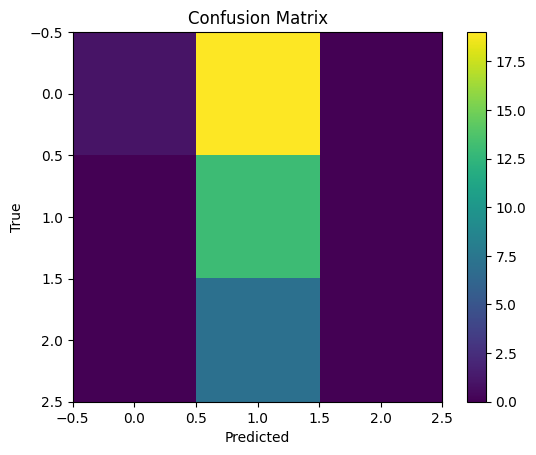

In [17]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

print(cm)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [18]:
torch.save(model.state_dict(), "galaxy_model.pth")

print("Model saved successfully")

Model saved successfully
